<a href="https://colab.research.google.com/github/yashshinde0607/DS_LAB_SE_B_67/blob/main/DSLAB7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving HousingData.xls to HousingData.xls


First 5 rows of the dataset:

      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD  TAX  PTRATIO  \
0  0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07   0.0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18   0.0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18   0.0  0.458  7.147  54.2  6.0622    3  222     18.7   

        B  LSTAT  MEDV  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90    NaN  36.2  

Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non

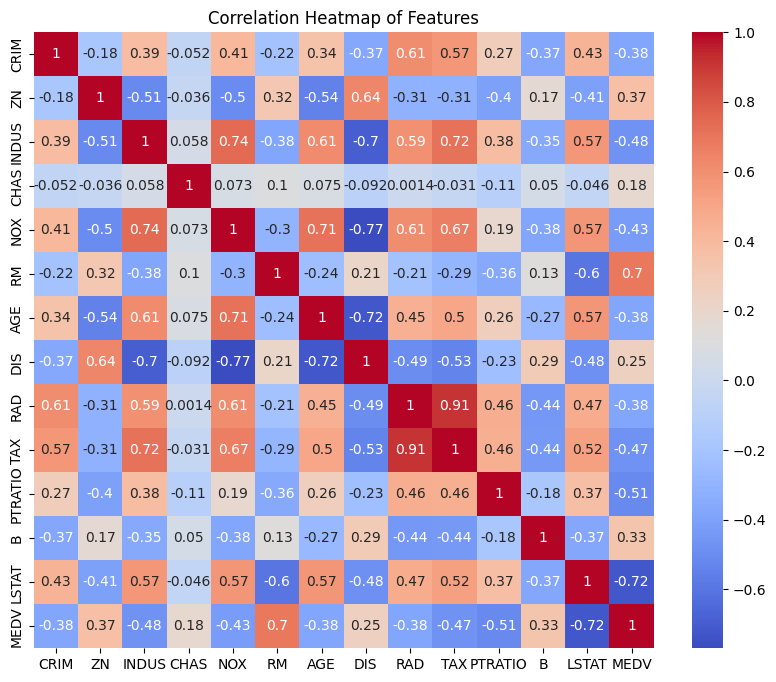


Training Data Size: (404, 13)
Testing Data Size: (102, 13)

Intercept of the model: 27.912465201030926

Coefficients of each feature:

         Coefficient Value
CRIM             -0.114140
ZN                0.029016
INDUS            -0.027133
CHAS              3.240673
NOX             -16.017543
RM                4.752410
AGE              -0.019520
DIS              -1.521593
RAD               0.222823
TAX              -0.009151
PTRATIO          -0.886045
B                 0.012263
LSTAT            -0.438440

Comparison of Actual and Predicted House Prices:

     Actual House Price  Predicted House Price
173                23.6              29.143250
274                32.4              36.535668
491                13.6              14.492513
72                 22.8              25.081110
452                16.1              18.456092

Model Evaluation Results:

Mean Absolute Error: 3.1499233573457692
Mean Squared Error: 25.01767202384268
Root Mean Squared Error: 5.0017668901941725
R-s

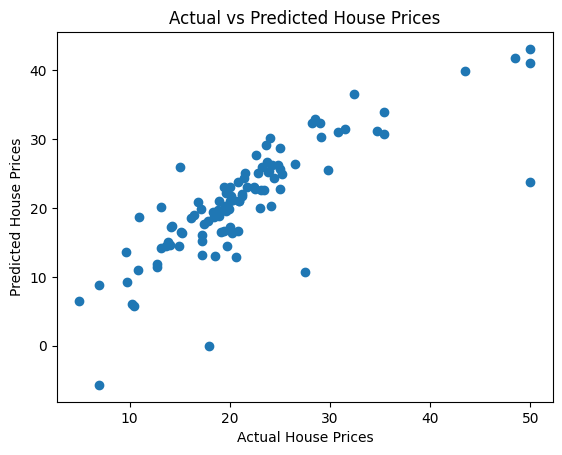

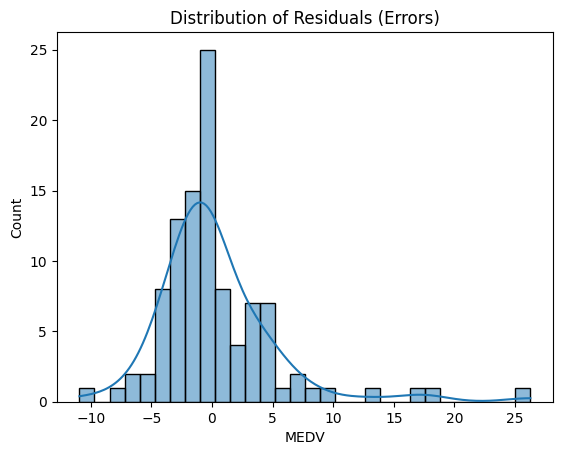

In [ ]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

# Load dataset (works even if file is actually CSV with .xls name)
df = pd.read_csv("HousingData.xls")

# Display first 5 rows
print("First 5 rows of the dataset:\n")
print(df.head())

# Handle missing values by replacing with mean
df = df.fillna(df.mean())

# Display dataset information
print("\nDataset Information:\n")
print(df.info())

# Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap of Features")
plt.show()

# Separate features and target variable
X = df.drop("MEDV", axis=1)
y = df["MEDV"]

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nTraining Data Size:", X_train.shape)
print("Testing Data Size:", X_test.shape)

# Create Linear Regression model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

# Display intercept and coefficients
print("\nIntercept of the model:", model.intercept_)
print("\nCoefficients of each feature:\n")
print(pd.DataFrame(model.coef_, X.columns, columns=["Coefficient Value"]))

# Predict house prices
y_pred = model.predict(X_test)

# Compare actual vs predicted values
comparison = pd.DataFrame({
    "Actual House Price": y_test,
    "Predicted House Price": y_pred
})

print("\nComparison of Actual and Predicted House Prices:\n")
print(comparison.head())

# Evaluation metrics with full forms
print("\nModel Evaluation Results:\n")

mean_absolute_error = metrics.mean_absolute_error(y_test, y_pred)
mean_squared_error = metrics.mean_squared_error(y_test, y_pred)
root_mean_squared_error = np.sqrt(mean_squared_error)
r_squared_score = metrics.r2_score(y_test, y_pred)

print("Mean Absolute Error:", mean_absolute_error)
print("Mean Squared Error:", mean_squared_error)
print("Root Mean Squared Error:", root_mean_squared_error)
print("R-squared Score:", r_squared_score)

# Scatter plot for Actual vs Predicted values
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Actual vs Predicted House Prices")
plt.show()

# Residual distribution plot
plt.figure()
sns.histplot(y_test - y_pred, bins=30, kde=True)
plt.title("Distribution of Residuals (Errors)")
plt.show()

First 5 rows of the dataset:

      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD  TAX  PTRATIO  \
0  0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07   0.0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18   0.0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18   0.0  0.458  7.147  54.2  6.0622    3  222     18.7   

        B  LSTAT  MEDV  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90    NaN  36.2  

Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non

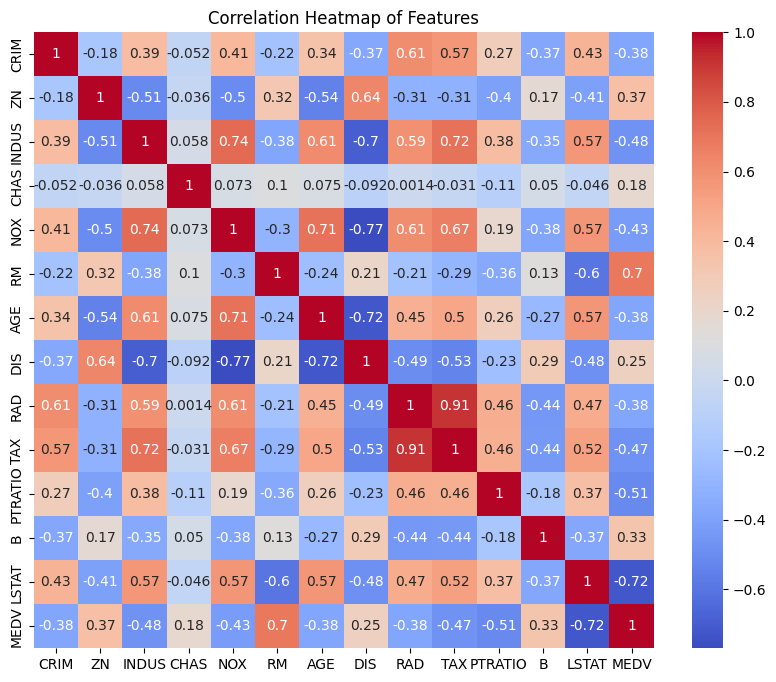


Training Data Size: (404, 13)
Testing Data Size: (102, 13)

Intercept of the model: 27.912465201030926

Coefficients of each feature:

         Coefficient Value
CRIM             -0.114140
ZN                0.029016
INDUS            -0.027133
CHAS              3.240673
NOX             -16.017543
RM                4.752410
AGE              -0.019520
DIS              -1.521593
RAD               0.222823
TAX              -0.009151
PTRATIO          -0.886045
B                 0.012263
LSTAT            -0.438440

Comparison of Actual and Predicted House Prices (in Indian Rupees):

     Actual Price (in Rupees)  Predicted Price (in Rupees)  \
173                 1958800.0                 2.418890e+06   
274                 2689200.0                 3.032460e+06   
491                 1128800.0                 1.202879e+06   
72                  1892400.0                 2.081732e+06   
452                 1336300.0                 1.531856e+06   

     Actual Price (in Lakhs ₹)  Predicted P

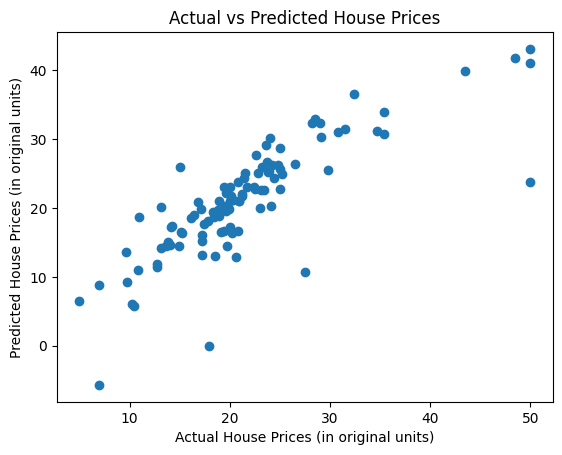

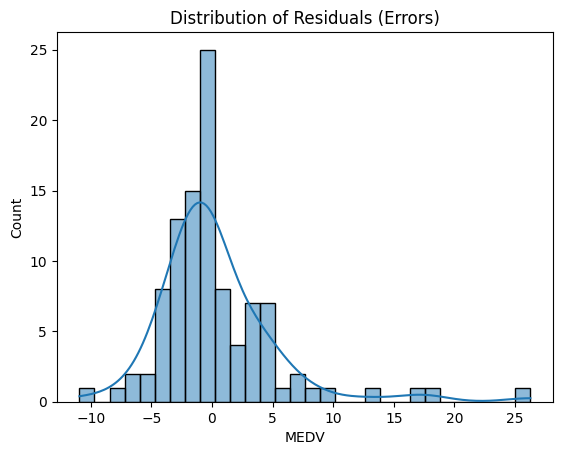

In [ ]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

# Load dataset (works even if .xls is actually CSV)
df = pd.read_csv("HousingData.xls")

# Display first 5 rows
print("First 5 rows of the dataset:\n")
print(df.head())

# Handle missing values
df = df.fillna(df.mean())

# Dataset information
print("\nDataset Information:\n")
print(df.info())

# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap of Features")
plt.show()

# Features and target variable
X = df.drop("MEDV", axis=1)
y = df["MEDV"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nTraining Data Size:", X_train.shape)
print("Testing Data Size:", X_test.shape)

# Create and train model
model = LinearRegression()
model.fit(X_train, y_train)

# Model parameters
print("\nIntercept of the model:", model.intercept_)
print("\nCoefficients of each feature:\n")
print(pd.DataFrame(model.coef_, X.columns, columns=["Coefficient Value"]))

# Predictions
y_pred = model.predict(X_test)

# -------------------------------
# Convert Prices to Indian Rupees
# -------------------------------
usd_to_inr = 83  # exchange rate

actual_price_rupees = y_test * 1000 * usd_to_inr
predicted_price_rupees = y_pred * 1000 * usd_to_inr

# Comparison table
comparison = pd.DataFrame({
    "Actual Price (in Rupees)": actual_price_rupees,
    "Predicted Price (in Rupees)": predicted_price_rupees
})

# Optional: Convert to Lakhs
comparison["Actual Price (in Lakhs ₹)"] = comparison["Actual Price (in Rupees)"] / 100000
comparison["Predicted Price (in Lakhs ₹)"] = comparison["Predicted Price (in Rupees)"] / 100000

print("\nComparison of Actual and Predicted House Prices (in Indian Rupees):\n")
print(comparison.head())

# -------------------------------
# Model Evaluation (Full Forms)
# -------------------------------
print("\nModel Evaluation Results:\n")

mean_absolute_error = metrics.mean_absolute_error(y_test, y_pred)
mean_squared_error = metrics.mean_squared_error(y_test, y_pred)
root_mean_squared_error = np.sqrt(mean_squared_error)
r_squared_score = metrics.r2_score(y_test, y_pred)

print("Mean Absolute Error:", mean_absolute_error)
print("Mean Squared Error:", mean_squared_error)
print("Root Mean Squared Error:", root_mean_squared_error)
print("R-squared Score:", r_squared_score)

# -------------------------------
# Graphs
# -------------------------------

# Scatter plot
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual House Prices (in original units)")
plt.ylabel("Predicted House Prices (in original units)")
plt.title("Actual vs Predicted House Prices")
plt.show()

# Residual plot
plt.figure()
sns.histplot(y_test - y_pred, bins=30, kde=True)
plt.title("Distribution of Residuals (Errors)")
plt.show()